Contenido:

-Probabilidad Laplaciana (montecarlo)

-Probabilidad Frecuentista

-Probabilidad Geométrica (Encuentro)


# La variable aleatoria asociada al evento $S_{n}$

Sea el experimento aleatorio de lanzar dos dados. Entonces

$$ \Omega = \{ (i,j) \mid i,j\in \{1,\dots,6\} \}$$

Sea el evento $S_n$: la suma de los dados es $n$, es decir,

$$ S_n = \{(i,j)\in\Omega \mid i+j=n\} $$

In [ ]:
from fractions import Fraction # Para trabajar con fracciones de manera precisa

In [ ]:
# Definimos la función de probabildiad P(A) que toma un evento A y devuelve su probabilidad como una fracción.
def P(A):
    P = Fraction(len(A),len(Omega))
    return P

# Vamos a introducir qué es un diccionario en Python

Un diccionario en Python es una estructura de datos que guarda información en pares **llave-valor** o **clave-valor** .  

Cada llave permite acceder al valor que tiene asociado.

$$ \{ \text{key} : \text{valor} \} $$

Ejemplo:

```python
diccionario = {"nombre": "Ana", "edad": 25}

In [ ]:
diccionario = {"nombre": "Ana", "edad": 25}
diccionario

{'nombre': 'Ana', 'edad': 25}

**Nota:** No es recomendable usar **dict** como nombre de variable, porque dict es una función incorporada de Python.

In [ ]:
dic = {
    'Claudia': ['Masha', 'Snow'], # Lista de mascotas de Claudia
    'Calificaciones': [10, 9.5, 8], # Lista de calificaciones de Claudia
    'Documento': ['G2436798'] # Lista de documentos de Claudia
}

In [ ]:
# Si queremos acceder a las calificaciones de Claudia, podemos hacerlo utilizando la clave 'Calificaciones':
calif = dic['Calificaciones']
calif

[10, 9.5, 8]

In [ ]:
# Si queremos acceder a la primera calificación de Claudia, podemos hacerlo utilizando el índice 0:
dic['Calificaciones'][0]

10

Si quisieras organizar información de personas o mascotas de forma más clara, podría convenir algo como esto:

In [ ]:
dic1 = {
    'Nombre': 'Claudia',
    'Mascotas': ['Masha', 'Snow'],
    'Calificaciones': [10, 9.5, 8],
    'Documentos': ['G2436798', 'G2736798', 'G279398']
}
dic1

{'Nombre': 'Claudia',
 'Mascotas': ['Masha', 'Snow'],
 'Calificaciones': [10, 9.5, 8],
 'Documentos': ['G2436798', 'G2736798', 'G279398']}

### Otra forma de crear diccionarios

Otra forma de crear diccionarios en Python es usando `dict()`.

En este caso, `dict()` recibe una lista de tuplas, donde cada tupla tiene la forma `(llave, valor)`.

```python
dic2 = dict([
    ('Claudia', ['Masha', 'Snow']),
    ('Calif', [10, 9.5, 8]),
    ('Doc', ['G2436798', 'G2736798', 'G279398'])
])

In [ ]:
dic2 = dict([('Claudia', ['Masha', 'Snow']),
             ('Calif', [10, 9.5, 8]),
             ('Doc', ['G2436798', 'G2736798', 'G279398'])])
dic2

{'Claudia': ['Masha', 'Snow'],
 'Calif': [10, 9.5, 8],
 'Doc': ['G2436798', 'G2736798', 'G279398']}

`type()` es una función de Python que permite saber el tipo de un objeto, es decir, responde a ¿de qué tipo es esto?. Es una estructura `type(objeto)`

Por ejemplo:

```python
type(5)        # int
type(3.14)     # float
type("Hola")   # str
type([1,2,3])  # list
type({'a':1})  # dict

 Entonces `type(dic)` sirve para ver qué tipo de objeto es dic en ese momento.

In [ ]:
type(3.14)

float

Las llaves del diccionario se muestran de la siguiente manera `dic.keys()`

In [ ]:
dic.keys()

dict_keys(['Claudia', 'Calificaciones', 'Documento'])

Los valores del diccionario se muestran de la siguiente manera `dic.values()`

In [ ]:
dic.values()

dict_values([['Masha', 'Snow'], [10, 9.5, 8], ['G2436798']])

In [ ]:
# Generamos el espacio muestral de lanzar dos dados utilizando el producto cartesiano
from itertools import product
Omega = set(product([1,2,3,4,5,6],repeat=2))

In [ ]:
# Vamos a crear un diccionario para el evento S_n
Sn = { (i,j) : i+j for i,j in Omega } # asociamos a cada par de números la suma de ambos números
Sn

{(3, 4): 7,
 (4, 3): 7,
 (3, 1): 4,
 (5, 4): 9,
 (4, 6): 10,
 (5, 1): 6,
 (2, 2): 4,
 (1, 6): 7,
 (2, 5): 7,
 (1, 3): 4,
 (6, 2): 8,
 (6, 5): 11,
 (4, 2): 6,
 (4, 5): 9,
 (3, 3): 6,
 (5, 6): 11,
 (3, 6): 9,
 (5, 3): 8,
 (2, 4): 6,
 (1, 2): 3,
 (2, 1): 3,
 (1, 5): 6,
 (6, 1): 7,
 (6, 4): 10,
 (3, 2): 5,
 (4, 1): 5,
 (3, 5): 8,
 (5, 2): 7,
 (4, 4): 8,
 (5, 5): 10,
 (1, 1): 2,
 (1, 4): 5,
 (2, 3): 5,
 (2, 6): 8,
 (6, 6): 12,
 (6, 3): 9}

Vamos a agrupar combinaciones por suma

Usamos `defaultdict(set)` para crear un diccionario cuyas claves tendrán como valor un conjunto vacío por defecto.

**Nota:** es útil cuando queremos agrupar resultados sin tener que verificar primero si la llave ya existe en el diccionario.

In [ ]:
# Vamos a agrupar combinaciones por suma (mismo resultado)
from collections import defaultdict # Creamos un diccionario que por defecto crea un conjunto vacío para cada nueva clave
dSn = defaultdict(set) # Recorremos el diccionario Sn y agrupamos las combinaciones por su suma

Ahora vamos a recorrer los elementos del diccionario `Sn`

In [ ]:
for i,j in Sn.items():
    dSn[j].add(i) # i es la llave (a,b) y j es a+b

¿Qué significa lo anterior?

- Usamos `Sn.items()` para recorrer simultáneamente las llaves y los valores del diccionario.
- En este caso:
  - `i` es la clave, es decir, un par `(a,b)`
  - `j` es el valor asociado, es decir, la suma `a+b`
- Luego `dSn[j].add(i)` agrega el par `(a,b)` al conjunto correspondiente a la suma `j`.

Básicamente, tenemos

```python
for pareja, suma in S.items():
    dS[suma].add(pareja)

In [ ]:
# Para visualizar la lista (suma, pares ordenados)
list(dSn.items())

[(7, {(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}),
 (4, {(1, 3), (2, 2), (3, 1)}),
 (9, {(3, 6), (4, 5), (5, 4), (6, 3)}),
 (10, {(4, 6), (5, 5), (6, 4)}),
 (6, {(1, 5), (2, 4), (3, 3), (4, 2), (5, 1)}),
 (8, {(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)}),
 (11, {(5, 6), (6, 5)}),
 (3, {(1, 2), (2, 1)}),
 (5, {(1, 4), (2, 3), (3, 2), (4, 1)}),
 (2, {(1, 1)}),
 (12, {(6, 6)})]

El método `items()` devuelve los pares **llave-valor** del diccionario `dSn`.

En este caso:

- la **llave** es una suma,
- el **valor** es el conjunto de pares ordenados que producen esa suma.

Al aplicar `list(dS.items())`, convertimos esos elementos en una lista para visualizarlos de forma más clara.

## La ley de una variable aleatoria

Recordemos que una variable aleatoria real $X$ es una función $X: \Omega \to \mathbb{R}$

Sabemos que la **ley de una variable aleatoria discreta** $X$ (es la función de densidad, función de masa de probabilidad), se define como sigue:

$$ f_{X}(x) = \begin{cases} \mathbb{P}(X=x), \quad \text{si } x\in R_{X} \\ \qquad 0, \quad \text{en otro caso} \end{cases} $$

donde $R_{X}$ es el rango de la variable aleatoria $X$.

Para nuestro evento $S_{n}$ se tiene la siguiente variable aleatoria:

$$S_n : \Omega \to \{ 2,3,4,5,6,7,8,9,10,11,12 \}$$

`LeySn` almacena la probabilidad de cada posible suma. Usamos la función `P(A)`, construimos un diccionario que asigna a cada suma su probabilidad.

Aquí, `A` representa el conjunto de pares ordenados que producen la suma `i`.

In [ ]:
# Creando la función de densidad de S_n, que es la probabilidad de cada suma i,
# que se obtiene dividiendo el número de pares ordenados que producen la suma i entre el total de pares ordenados (36).

LeySn = { i : P(A) for i,A in dSn.items() }
LeySn

{7: Fraction(1, 6),
 4: Fraction(1, 12),
 9: Fraction(1, 9),
 10: Fraction(1, 12),
 6: Fraction(5, 36),
 8: Fraction(5, 36),
 11: Fraction(1, 18),
 3: Fraction(1, 18),
 5: Fraction(1, 9),
 2: Fraction(1, 36),
 12: Fraction(1, 36)}

La librería `pandas` se usa para manipular y analizar datos en Python.

La abreviatura `pd` es un alias que facilita su uso.

In [ ]:
# Importamos la libreria Pandas
import pandas as pd

Usamos `pd.Series()` para convertir el diccionario `LeySn` en una Serie de pandas.

In [ ]:
# Vamos a crear una Serie
Ley_Sn = pd.Series(LeySn)
Ley_Sn

7      1/6
4     1/12
9      1/9
10    1/12
6     5/36
8     5/36
11    1/18
3     1/18
5      1/9
2     1/36
12    1/36
dtype: object

En esta Serie:
- el índice corresponde a las sumas posibles,
- los valores corresponden a las probabilidades asociadas a cada suma.

In [ ]:
# Para ordenar la Serie
Ley_Sn = Ley_Sn.sort_index() #odenar ascendente por índice
# Ley_S = Ley_S.sort_index(ascending=False) #ordenar descendente por índice
Ley_Sn

2     1/36
3     1/18
4     1/12
5      1/9
6     5/36
7      1/6
8     5/36
9      1/9
10    1/12
11    1/18
12    1/36
dtype: object

In [ ]:
import numpy as np

In [ ]:
# Definimos la función de densidad
# LeyS(i) devuelve la probabilidad de obtnener la suma i, si i está en el rango

def LeyS(i):
    if i in range(2,13): # es de 2 hasta 12
        x = Ley_Sn[i]
    else:
        x = 0 # no me asigne probabilidad
    return x

In [ ]:
# Vamos a crear el rango de Sn

rango_S = [k for k in range(2,13)]

# Obtener la probabilidad de cada suma en el rango de S
p_k = [float(LeyS(k)) for k in rango_S]

In [ ]:
# Para verificar que la suma de las probabilidades es 1
sum(p_k)
# Funciona para listas, tuplas, arrays de numpy, range, generadores, sumar valores del diccionario

1.0

In [ ]:
# Creamos un DataFrame:
# los valores del rango de S (rango_S)
# las probabilidades de cada suma (p_k)
# Indexamos una etiquerta s_2, s_3, ... , s_12

lS = pd.DataFrame(list(zip(rango_S,p_k)), #zip srive para enparejar elementos de dos listas
                  index = [f'S_{k}' for k in rango_S],
                  columns = ['rango', 'densidad'])
lS

,rango,densidad
S_2,2,0.027778
S_3,3,0.055556
S_4,4,0.083333
S_5,5,0.111111
S_6,6,0.138889
S_7,7,0.166667
S_8,8,0.138889
S_9,9,0.111111
S_10,10,0.083333
S_11,11,0.055556


<Axes: xlabel='rango'>

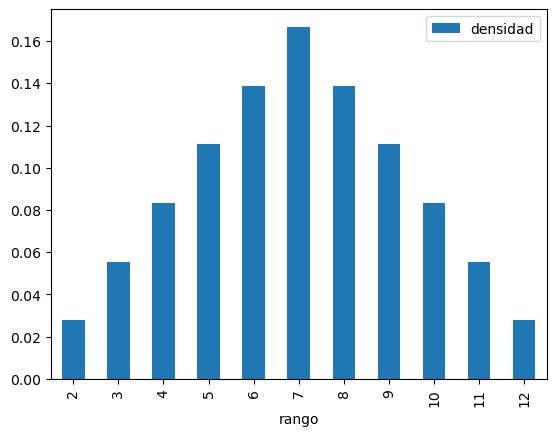

In [ ]:
lS.plot.bar( x = 'rango', y = 'densidad')

# 1. Probabilidad Laplaciana

Para un experimento aleatorio, se tiene que $\Omega$ es el espacio muestral (conjunto de posibles resultados).

Sea $A$ un evento, entonces defimos la probabilidad de $A$ como sigue:

$$ \mathbb{P}(A) = \frac{|A|}{|\Omega|}. $$

**Ejemplo.** Sea el experimento de lanzar una moneda 3 veces, de manera independiente, es decir, el $i$-ésimo lanzamiento no afecta al $i+1$ lanzamiento. El espacio muestral es:

$$ \Omega = \{A,S\} \times \{A,S\} \times \{A,S\} = \{A,S\}^{3} , A=\{águlas\}, S=\{soles\}$$

$$ A \times B = \{(a,b) \mid a\in A, b\in B\} $$
y
$$\Omega = \{ (s,s,s),(s,a,s),(s,s,a),(s,a,a),(a,a,a),(a,s,a),(a,s,s),(a,a,s) \}$$

y se tiene que $|\Omega|= 2^3 = 8$.

Sean los eventos:
  * $A$: todos los resultados son águila
  * $S$: todos los resultados son soles
  * $E$: por lo menos un resultado es sol (1 o 2 o 3 son soles)

Vamos a calculas las probabilidades de $A,S$ y $E$.

Primero para el evento $A$, vamos a descomponer al conjunto de la siguiente manera

$$A = A_1 \cap A_2 \cap A_3,$$
donde $A_i$: cae águila en el $i$-ésimo lanzamiento.


### Vamos a crear el espacio muestral

https://docs.python.org/3/library/itertools.html

In [ ]:
# Vamos a importar el siguiente modulo
import itertools
from itertools import product

In [ ]:
# set -> lo convierte en conjunto
# product -> generar las tuplas de longitud 3
Omega = set(product({"A","S"}, repeat=3))
Omega

{('A', 'A', 'A'),
 ('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [ ]:
# La cardinalidad del conjunto es:
len(Omega)

8

### Vamos a creae el evento A

In [ ]:
# Para el evento A_1: el primer elemento es águila
A_1 = { om for om in Omega if om[0]=="A" }
A_1

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [ ]:
# Para el evento A_2: el segundo elemento es águila
A_2 = { om for om in Omega if om[1]=="A" }
A_2

{('A', 'A', 'A'), ('A', 'A', 'S'), ('S', 'A', 'A'), ('S', 'A', 'S')}

In [ ]:
# Para el evento A_3: el tercer elemento es águila
A_3 = { om for om in Omega if om[2]=="A" }
A_3

{('A', 'A', 'A'), ('A', 'S', 'A'), ('S', 'A', 'A'), ('S', 'S', 'A')}

$$A \cap (B\cap C)$$

In [ ]:
# Para A se tiene
A = A_1.intersection(A_2.intersection(A_3))
A

{('A', 'A', 'A')}

In [ ]:
card_A = len(A)

In [ ]:
P_A = card_A / len(Omega)
P_A

0.125

Ahora, si quiero expresar mi resultado en fracción, utilizo https://docs.python.org/3/library/fractions.html

In [ ]:
from fractions import Fraction

In [ ]:
# Definimos la función de probabilidad Laplaciana
def p(E,Omega):
    p = Fraction(len(E),len(Omega))
    return p

In [ ]:
Pro_A = p(A,Omega)
Pro_A

Fraction(1, 8)

In [ ]:
# Forzamos a escribirlo de manera más amigable
print(Pro_A)

1/8


## Probabilidad Condicional

Si añadimos condiciones a nuestro experimento aleatorio, la probabilidad cambia.

Definimos  la probabilidad de que ocurra un evento $A$ **sabiendo** que ocurre un evento $B$, de la siguiente manera:

$$\mathbb{P}(A \mid B) = \frac{\mathbb{P}(A \cap B)}{\mathbb{P}(B)} = \frac{|A \cap B|}{|B|},$$
donde $\mathbb{P}(B)>0$.

In [ ]:
# Vamos a definir la función de probabilidad condicional

def prob_cond(E,F):
    return len(E & F) / len(F)

Queremos calcular la probabilidad condicional de los eventos:
  * $B$: el primer lanzamiento es águila
  * $C$: dos de los resultados son águila (exactamente)
    
Quiero calcular $\mathbb{P}(B\mid C)$:

In [ ]:
# Para el evento B: el primer elemento es águila
B = { om for om in Omega if om[0]=="A" }
B

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [ ]:
# Para el evento C: dos de los resulatados son águila
C = { om for om in Omega if om.count("A")==2 }
C

{('A', 'A', 'S'), ('A', 'S', 'A'), ('S', 'A', 'A')}

In [ ]:
prob_cond(B,C)

0.6666666666666666

In [ ]:
prob_cond(C,B)

0.5

## Independencia de eventos

Decimos que dos eventos $A$ y $B$ son independientes si

$$ \mathbb{P}(A\cap B) = \mathbb{P}(A)\mathbb{P}(B) $$

In [ ]:
def prob(E):
    return len(E) / len(Omega)

In [ ]:
def indep(E,F):
    return prob(E & F) == prob(E)*prob(F)

In [ ]:
indep(B,C)

False

**Ejemplo** Sea el experimento aleatorio de lanzar un dado honesto 2 veces. Sabemos que

$$\Omega = \{(i,j) \mid i,j\in \{1,2,3,4,5,6\} \} $$

y además $|\Omega|= 6^2 = 36$

In [ ]:
Omega_dado = set(product([1,2,3,4,5,6],repeat=2))
#Omega_dado

In [ ]:
card_dado = len(Omega_dado)
card_dado

36

Definimos el evento
   * $S_n$: la suma de los dados es $n$, donde $n\in\{2,\dots,12\}$.
$$ S_n = \{(i,j)\in \Omega \mid i+j =n \}$$

In [ ]:
# Definimos S_n
def S(n):
    Sn = { (i,j) for i in range(1,7) for j in range(1,7) if i+j == n }
    # range genera una secuencia de númerps enteros del 1 al 6
    return Sn

In [ ]:
S_nueve = S(9)
S_nueve

{(3, 6), (4, 5), (5, 4), (6, 3)}

In [ ]:
S_siete = S(7)
S_siete

{(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}

In [ ]:
len(S_siete) / card_dado

0.16666666666666666

# 2. Probabilidad Frecuentista

**Jacob Bernoulli** en 1713 formuló y demostró una versión temprana de la ley de los grandes números.

Sea un espacio muestral (un conjunto finito) y podemos definir la probabilidad asociada a un evento $A$ doonde tengo un experiemento aleatorio que se realizar $n$ veces:

$$ f_{n}(A) = \frac{n(A)}{n} $$

donde $n(A)$ es el número de veces en que ocuure $A$.


Sea el experimento aleatorio de lanzar una moneda (no justa).

In [ ]:
import random # para generar número aleatorios
def volado(p): # regresa la proba de obtener sol
    return "sol" if random.random() < p else "águila"
    # random.random() genera un número entre 0 y 1

In [ ]:
volado(0.4) # hay un 40% de obtener sol

'sol'

In [ ]:
# Vamos a realizar 10 volados con p=0.4
vol = [volado(0.4) for i in range(10)] # crear una lista
# range(n) crea un contador que va del 0 al 9 (repetir n veces )
vol

['águila',
 'águila',
 'águila',
 'águila',
 'sol',
 'águila',
 'águila',
 'águila',
 'sol',
 'sol']

In [ ]:
# Para contar el número de soles en una lista
vol.count("sol")

3

In [ ]:
# Para contar el número de águilas en una lista
vol.count("águila")

7

Otra manera sería por medio de un bucle:

In [ ]:
resultados = [] # lista vacía
for i in range(10):
    resultado = volado(0.4)
    resultados.append(resultado)
resultados

['águila',
 'sol',
 'sol',
 'águila',
 'águila',
 'águila',
 'águila',
 'sol',
 'águila',
 'sol']

Ahora, vamos a simular nuestra probabilidad frecuentista:

Un experimento con 1,000 volados (individual) y puedo repetir 500 experimentos (500 de nosotros)

In [ ]:
# Creamos una lista vacía para almacenar probabilidades (fecuencia)
p = []

for i in range(1000): # realizamos 500 experimentos
    N = 1000 # cada experimento tiene 1000 volados
    resultados = [] # almacene "sol" o "águila"

    for j in range(N):
        resultado = volado (0.63)
        resultados.append(resultado)


    n_soles = resultados.count("sol") # cuenta el # de soles
    p_soles = n_soles / N # proba frecuentista

    # Añadir estas probabilidades a la lista p
    p.append(p_soles)

    # probabilida frecuentista promedio
    p_soles_prom = sum(p) / 1000 # Por la Ley de los Grandes Números

p_soles_prom

0.629605

# 3. Probabilidad Geométrica

# El problema del encuentro


Romeo y Julieta planean encontrarse en un lugar específico entre $[0,60]$ minutos (1 hora).

- Si Romero llega primero, entonces piensa esperar 10 minutos
- Si Julieta llega primero, entonces piensa esperar 10 minutos

Se elige un número al azar entre $[0,60]$, y supongamos que el par de números se elige sobre el cuadrado de modo que la probabilidad de un evento sea el área favorable entre el área total.

Sea

$A$: Romero y Juliera se encuentran a una distancia de 10 minutos

me gustaría encontrar la probabilida de $A$.